# Enzyme Design Pipeline (Colab)
RFD3 → MPNN → RF3

This notebook runs the computational enzyme design pipeline entirely on Google Colab. It scaffolds a known theozyme — fixing the catalytic residues and small-molecule ligand geometry while designing a surrounding protein scaffold from scratch.

This is a translation of the DTU HPC version; the computational steps are identical but LSF job submission is replaced by direct in-notebook execution.

**Example target**: Serine hydrolase (PDB: 5XH3), Ser-Asp-His catalytic triad.

## Step 0: Colab Setup

Run this cell first, every session. It:
1. Mounts your Google Drive
2. Installs required Python packages
3. Clones LigandMPNN (public)
4. Adds support scripts to the Python path

> **One-time instructor setup**: See `CHECKPOINT.md` for the Drive folder structure and which model weights to upload.

In [1]:
# ── Python version check (rc-foundry requires 3.12) ──────────────────────────
import sys
assert sys.version_info >= (3, 12), (
    f'This notebook requires Python 3.12+. You have {sys.version}. '
    'In Colab: Runtime → Change runtime type → Python 3.12'
)
print(f'Python {sys.version_info.major}.{sys.version_info.minor} ✓')

# ── Mount Drive ──────────────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

# ── Drive paths (adjust if your folder name differs) ─────────────────────────
DRIVE_BASE      = '/content/drive/MyDrive/protein_design'
MODELS_DIR      = f'{DRIVE_BASE}/models'
SCRIPTS_DIR     = f'{DRIVE_BASE}/support'
INPUTS_DIR      = f'{DRIVE_BASE}/inputs'
LIGANDMPNN_DIR  = f'{DRIVE_BASE}/LigandMPNN'

import subprocess, glob as _glob, os, re

# ── Suppress wandb login prompts (rc-foundry imports wandb at startup) ────────
os.environ['WANDB_DISABLED'] = 'true'
os.environ['WANDB_MODE']     = 'disabled'

# ── Install rc-foundry (provides rfd3 + rf3 + mpnn CLIs) ─────────────────────
wheel = _glob.glob(f'{MODELS_DIR}/rc_foundry-*.whl')
if wheel:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', wheel[0]], check=True)
    print(f'Installed {os.path.basename(wheel[0])}')
else:
    print('Wheel not found on Drive — installing from GitHub (slower)...')
    subprocess.run(
        [sys.executable, '-m', 'pip', 'install', '-q',
         'rc-foundry[all] @ git+https://github.com/RosettaCommons/foundry.git'],
        check=True
    )

# ── Reinstall torchvision matched to the installed torch + CUDA version ───────
import torch

# RF3 cuEquivariance kernels require Ampere+ GPUs (SM 80+) in this build.
# Pre-Ampere GPUs such as V100 (SM 70) and T4 (SM 75) need this disabled.
def configure_rf3_gpu_flags():
    if not torch.cuda.is_available():
        print('CUDA unavailable: leaving RF3 cuEquivariance settings unchanged.')
        return
    major, minor = torch.cuda.get_device_capability()
    sm = major * 10 + minor
    if sm < 80:
        os.environ['DISABLE_CUEQUIVARIANCE'] = '1'
        print(f'GPU SM {sm}: disabling cuEquivariance for RF3.')
    else:
        os.environ.pop('DISABLE_CUEQUIVARIANCE', None)
        print(f'GPU SM {sm}: cuEquivariance enabled for RF3.')

configure_rf3_gpu_flags()
cuda_tag = ('cu' + torch.version.cuda.replace('.', '')) if torch.cuda.is_available() else 'cpu'
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'torchvision',
    '--index-url', f'https://download.pytorch.org/whl/{cuda_tag}'], check=True)
print(f'torchvision reinstalled for torch {torch.__version__} / {cuda_tag}')

# ── Install remaining dependencies ────────────────────────────────────────────
def _pip(*pkgs):
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', *pkgs], check=True)

_pip('biopython', 'numpy', 'pandas', 'scipy', 'matplotlib', 'seaborn', 'rdkit',
     'prody',            # LigandMPNN
     'ml-collections',   # LigandMPNN / OpenFold
     'dm-tree')          # LigandMPNN / OpenFold

# ── Clone LigandMPNN (public, small) ─────────────────────────────────────────
if not os.path.exists(LIGANDMPNN_DIR):
    subprocess.run(
        ['git', 'clone', 'https://github.com/dauparas/LigandMPNN.git', LIGANDMPNN_DIR],
        check=True
    )
    print('LigandMPNN cloned.')
else:
    print('LigandMPNN already present.')

# ── Patch LigandMPNN / OpenFold for NumPy >= 1.24 compatibility ──────────────
# np.int / np.float / np.bool / np.complex were removed in NumPy 1.24.
# This patch replaces them with the plain Python builtins (safe, behaviour-identical).
_DEPRECATED = re.compile(r'\bnp\.(int|float|bool|complex|str)\b(?![\d_])')
_patched = 0
for _root, _dirs, _files in os.walk(f'{LIGANDMPNN_DIR}/openfold'):
    for _fname in _files:
        if not _fname.endswith('.py'):
            continue
        _path = os.path.join(_root, _fname)
        _text = open(_path).read()
        _new  = _DEPRECATED.sub(lambda m: m.group(1), _text)
        if _new != _text:
            open(_path, 'w').write(_new)
            _patched += 1
print(f'NumPy compat patch applied to {_patched} file(s) in LigandMPNN/openfold.')

# ── Add support scripts to path ───────────────────────────────────────────────
if SCRIPTS_DIR not in sys.path:
    sys.path.insert(0, SCRIPTS_DIR)

print('Setup complete.')

Python 3.12 ✓
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Installed rc_foundry-0.1.11.dev33+ga86520dfa.d20260602-py3-none-any.whl
torchvision reinstalled for torch 2.7.1+cu126 / cu126
LigandMPNN already present.
NumPy compat patch applied to 0 file(s) in LigandMPNN/openfold.
Setup complete.


## Imports and directories

In [2]:
# --- Core ---
import os, sys, re, glob, json, math, shutil, random, string, csv
import itertools
from pathlib import Path
from collections import Counter, defaultdict, OrderedDict
from datetime import datetime
from copy import deepcopy

# --- Data / numerics ---
import numpy as np
import pandas as pd
from scipy.stats import gaussian_kde

# --- Plotting ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- BioPython ---
from Bio import SeqIO

# --- Notebook display ---
from IPython.display import display

# --- Shared utilities (loaded from Drive via SCRIPTS_DIR in sys.path) ---
import jupyter_utils  # provides write_rfd3_json

In [3]:
# ── Helper: stream a shell command's output in the notebook ───────────────────
def run_step(cmd, label=''):
    """Run a shell command, printing output line by line."""
    if label:
        print(f'\n{"-"*60}\n{label}\n{"-"*60}')
    print(f'$ {cmd}\n')
    proc = subprocess.Popen(cmd, shell=True, text=True,
                            stdout=subprocess.PIPE, stderr=subprocess.STDOUT)
    for line in proc.stdout:
        print(line, end='', flush=True)
    proc.wait()
    if proc.returncode != 0:
        raise RuntimeError(f'Command failed (exit {proc.returncode})')

In [4]:
# ── Campaign settings ─────────────────────────────────────────────────────────
student_name = 'student'           # change to your name
family       = 'hydrolases'
target       = 'serine_hydrolase'
campaign     = 'rd1'

working_dir = f'{DRIVE_BASE}/runs/{student_name}/enzyme_design/{family}/{target}/{campaign}'
os.makedirs(working_dir, exist_ok=True)
os.chdir(working_dir)

def setup_directories(base_dir, dirs_list):
    result = {}
    for dir_name in dirs_list:
        full_path = os.path.join(base_dir, dir_name)
        os.makedirs(full_path, exist_ok=True)
        result[dir_name + '_dir'] = full_path
    return result

wrk_dirs_list = ['cmds', 'logs', 'pics', 'configs', 'scores', 'inputs',
                 'diffusion_out', 'rf3_out', 'mpnn_out']
_dirs = setup_directories(working_dir, wrk_dirs_list)

cmds_dir          = _dirs['cmds_dir']
logs_dir          = _dirs['logs_dir']
pics_dir          = _dirs['pics_dir']
configs_dir       = _dirs['configs_dir']
scores_dir        = _dirs['scores_dir']
inputs_dir        = _dirs['inputs_dir']
diffusion_out_dir = _dirs['diffusion_out_dir']
rf3_out_dir       = _dirs['rf3_out_dir']
mpnn_out_dir      = _dirs['mpnn_out_dir']

# ── Copy input PDB from shared Drive inputs ───────────────────────────────────
for fname in ['5XH3.pdb']:
    src = f'{INPUTS_DIR}/{fname}'
    dst = f'{inputs_dir}/{fname}'
    if os.path.exists(src) and not os.path.exists(dst):
        shutil.copy2(src, dst)

print(f'Campaign : {family} / {target} / {campaign}')
print(f'Directory: {working_dir}')

Campaign : hydrolases / serine_hydrolase / rd1
Directory: /content/drive/MyDrive/protein_design/runs/student/enzyme_design/hydrolases/serine_hydrolase/rd1


## RFD3

RFdiffusion3 (RFD3) generates de novo backbone structures by diffusing from noise under constraints you define — here, the catalytic residues are fixed in their theozyme geometry while the surrounding scaffold is designed freely.

Full parameter reference: [RFD3 enzyme design docs](https://github.com/RosettaCommons/foundry/blob/production/models/rfd3/docs/enzyme_design.md)

Key parameters:
- **`contig`**: scaffold layout — free segments like `30-50` are designed from scratch; entries like `A58-58` copy a residue directly from the input PDB.
- **`catres`**: catalytic residues held fixed during MPNN sequence design.
- **`fixed_atoms`**: specific sidechain atoms to pin in place during diffusion (preserves catalytic geometry).
- **`ligand_name`**: must match the residue name in your input PDB.

In [5]:
dialect   = 2
input_pdb = f'{inputs_dir}/5XH3.pdb'

# Scaffold layout: free ranges interspersed with fixed motif residues
contig = '30-50,A58-58,40-60,A131-132,20-40,A177-177,20-40,A208,40-60'
length = '180-250'

ligand_name               = 'pt1'   # must match residue name in input PDB
redesign_motif_sidechains = False
is_non_loopy              = True
infer_ori_strategy        = None    # None for enzyme design (use 'hotspots' for binders)
hotspots                  = None

# Catalytic residues — MPNN will not redesign these
catres = ['A131', 'A177', 'A208']  # Ser, Asp, His (serine protease triad)

# Key sidechain atoms to pin during diffusion (preserves catalytic geometry)
fixed_atoms = {
    'A131': 'OG,CA,CB',
    'A177': 'OD1,OD2,CG,CB',
    'A208': 'NE2,ND1,CE1,CD2,CG',
}

select_hotspots       = {}
select_hbond_donor    = {}
select_hbond_acceptor = {}

### Run RFD3

> **Colab note**: Runs inference directly. `diffusion_batch_size=1` and `n_batches=2` keeps runtime under ~10 min on a T4. Increase for a real campaign.

In [6]:
RFD3_CKPT            = f'{MODELS_DIR}/rfd3_latest.ckpt'
diffusion_batch_size = 1   # increase for real campaign (was 2)
n_batches            = 2   # total designs = batch_size × n_batches

bn       = os.path.basename(input_pdb)[:-4]
json_f   = f'{configs_dir}/{bn}.json'
out_dir  = f'{diffusion_out_dir}/{bn}'
os.makedirs(out_dir, exist_ok=True)

# Write RFD3 config JSON
jupyter_utils.write_rfd3_json(
    json_f, input_pdb, contig, length,
    catres=','.join(catres), ligand=ligand_name,
    fixed_atoms=fixed_atoms, dialect=dialect,
    redesign_motif_sc=redesign_motif_sidechains,
    hotspots=hotspots, infer_ori_strategy=infer_ori_strategy
)
print(f'Config written → {json_f}')

cmd = (
    f'rfd3 design'
    f' out_dir={out_dir}'
    f' inputs={json_f}'
    f' ckpt_path={RFD3_CKPT}'
    f' diffusion_batch_size={diffusion_batch_size}'
    f' n_batches={n_batches}'
    f' inference_sampler.step_scale=3'
    f' inference_sampler.gamma_0=0.2'
)

run_step(cmd, label='RFD3 diffusion')
print('\nRFD3 finished.')

Config written → /content/drive/MyDrive/protein_design/runs/student/enzyme_design/hydrolases/serine_hydrolase/rd1/configs/5XH3.json

------------------------------------------------------------
RFD3 diffusion
------------------------------------------------------------
$ rfd3 design out_dir=/content/drive/MyDrive/protein_design/runs/student/enzyme_design/hydrolases/serine_hydrolase/rd1/diffusion_out/5XH3 inputs=/content/drive/MyDrive/protein_design/runs/student/enzyme_design/hydrolases/serine_hydrolase/rd1/configs/5XH3.json ckpt_path=/content/drive/MyDrive/protein_design/models/rfd3_latest.ckpt diffusion_batch_size=1 n_batches=2 inference_sampler.step_scale=3 inference_sampler.gamma_0=0.2

/usr/local/lib/python3.12/dist-packages/hydra/_internal/config_loader_impl.py:216: UserWarning: provider=hydra.searchpath in main, path=configs is not available.
  warnings.warn(
Environment variable CCD_MIRROR_PATH not set. Will not be able to use function requiring this variable. To set it you may:

### Process RFD3 outputs

In [7]:
rfd3_metrics_csv = f'{scores_dir}/rfd3_metrics_with_json_path.csv'

json_paths = sorted(glob.glob(f'{diffusion_out_dir}/*/*json'))
if not json_paths:
    raise SystemExit('No JSON files found — run RFD3 first.')

rows = []
all_keys = set(['json_path'])

for jp in json_paths:
    with open(jp, 'r') as f:
        data = json.load(f)
    metrics = data.get('metrics', {})
    row = {'json_path': os.path.abspath(jp)}
    for k, v in metrics.items():
        if k in ('diffused_com', 'fixed_com') and isinstance(v, (list, tuple)) and len(v) == 3:
            row[f'{k}_x'], row[f'{k}_y'], row[f'{k}_z'] = v
            all_keys.update({f'{k}_x', f'{k}_y', f'{k}_z'})
        else:
            row[k] = v
            all_keys.add(k)
    rows.append(row)

fieldnames = ['json_path'] + sorted(k for k in all_keys if k != 'json_path')

with open(rfd3_metrics_csv, 'w', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    for r in rows:
        writer.writerow(r)

print(f'Wrote {len(rows)} rows → {rfd3_metrics_csv}')
print('Columns:', fieldnames)

Wrote 2 rows → /content/drive/MyDrive/protein_design/runs/student/enzyme_design/hydrolases/serine_hydrolase/rd1/scores/rfd3_metrics_with_json_path.csv
Columns: ['json_path', 'alanine_content', 'diffused_com_x', 'diffused_com_y', 'diffused_com_z', 'fixed_com_x', 'fixed_com_y', 'fixed_com_z', 'glycine_content', 'helix_fraction', 'loop_fraction', 'max_ca_deviation', 'n_chainbreaks', 'n_clashing.interresidue_clashes_w_backbone', 'n_clashing.interresidue_clashes_w_sidechain', 'n_clashing.ligand_clashes', 'n_clashing.ligand_min_distance', 'non_loop_fraction', 'num_residues', 'num_ss_elements', 'radius_of_gyration', 'sheet_fraction']


### Inspect RFD3 metrics

Review output quality before moving to MPNN. Key columns:
- **`n_chainbreaks`**: must be 0 — broken chains are discarded before sequence design
- **`loop_fraction`**: lower is generally better
- **`n_clashing.*`**: structures with clashes are filtered before MPNN

In [8]:
df = pd.read_csv(rfd3_metrics_csv)
df.head(10)

,json_path,alanine_content,diffused_com_x,diffused_com_y,diffused_com_z,fixed_com_x,fixed_com_y,fixed_com_z,glycine_content,helix_fraction,...,n_chainbreaks,n_clashing.interresidue_clashes_w_backbone,n_clashing.interresidue_clashes_w_sidechain,n_clashing.ligand_clashes,n_clashing.ligand_min_distance,non_loop_fraction,num_residues,num_ss_elements,radius_of_gyration,sheet_fraction
0,/content/drive/MyDrive/protein_design/runs/stu...,0.634021,0.793364,0.037973,-0.730791,-0.000218,-0.000578,0.000662,0.087629,0.853403,...,0,0,1,0,1.983490,0.853403,194,8,17.324684,0.0
1,/content/drive/MyDrive/protein_design/runs/stu...,0.664894,-2.274018,0.730598,-2.012803,-0.000218,-0.000578,0.000662,0.074468,0.816216,...,0,0,0,0,1.958467,0.816216,188,9,16.134608,0.0


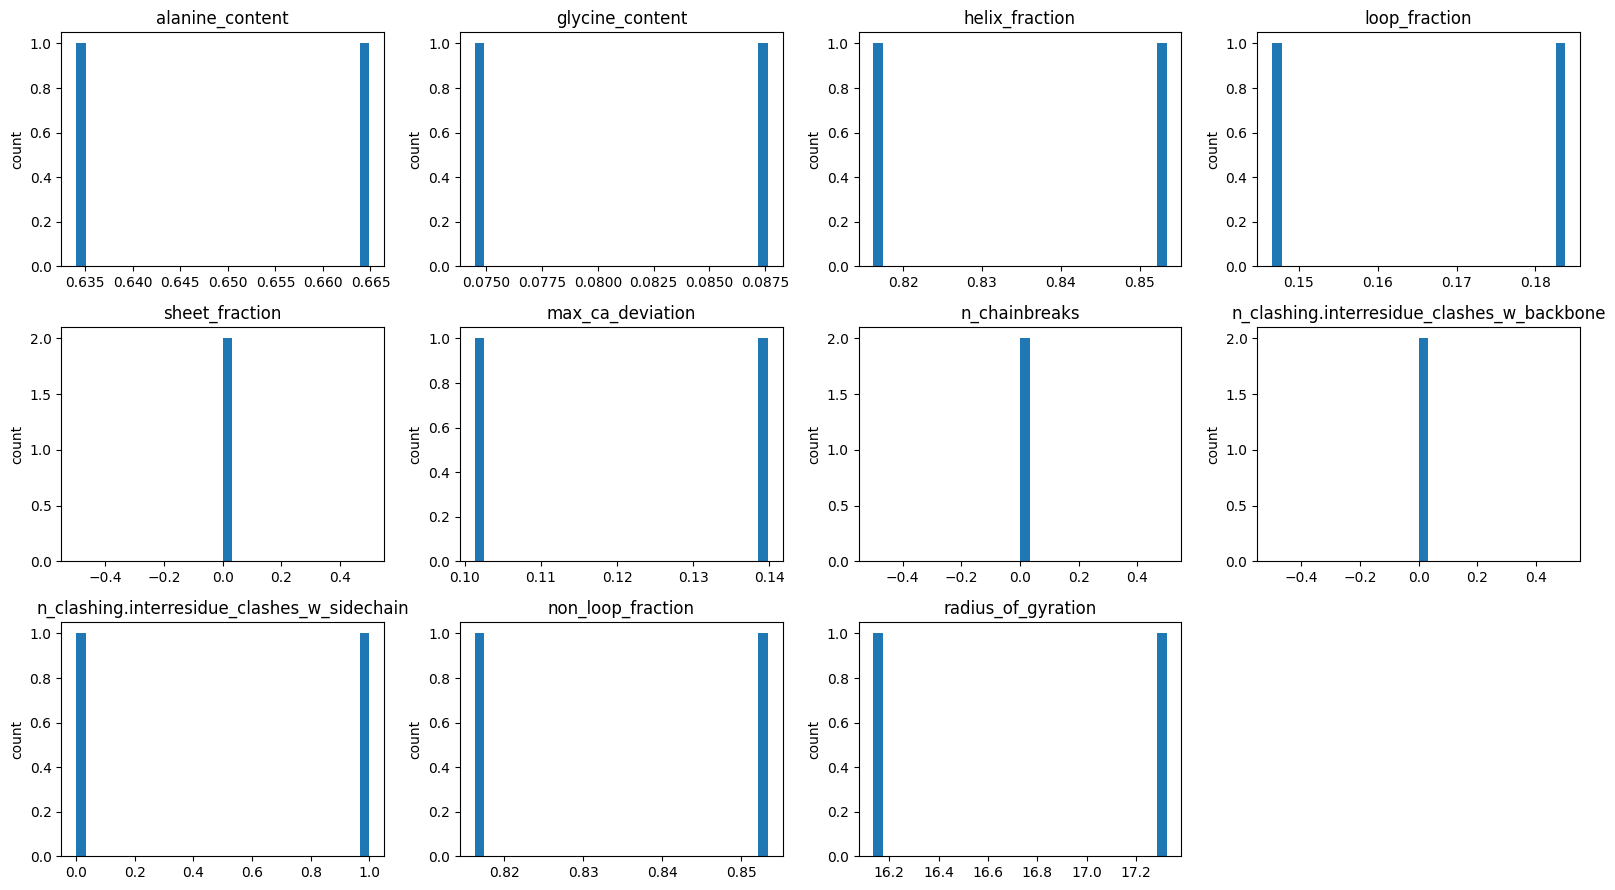

In [9]:
metrics = [
    'alanine_content', 'glycine_content', 'helix_fraction', 'loop_fraction',
    'sheet_fraction', 'max_ca_deviation', 'n_chainbreaks',
    'n_clashing.interresidue_clashes_w_backbone',
    'n_clashing.interresidue_clashes_w_sidechain',
    'non_loop_fraction', 'radius_of_gyration',
]
metrics = [m for m in metrics if m in df.columns]

n_cols = 4
n_rows = math.ceil(len(metrics) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows))
axes = axes.flatten()

def plot_hist(ax, series, title):
    s = series.dropna()
    if s.empty:
        ax.set_title(f'{title} (no data)'); ax.axis('off'); return
    ax.hist(s, bins=30)
    ax.set_title(title)
    ax.set_ylabel('count')

for ax, col in zip(axes, metrics):
    plot_hist(ax, df[col], col)
for ax in axes[len(metrics):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

## MPNN

LigandMPNN designs amino acid sequences onto each generated backbone, conditioning on the small-molecule ligand context. Catalytic residues are held fixed.

Structures with chain breaks or clashes are automatically discarded before sequence design, using the quality metrics already computed by RFD3 (no additional structural analysis tools required).

In [11]:
seed              = 42
batch_size        = 3
number_of_batches = 1
LMPNN_CKPT        = f'{MODELS_DIR}/ligandmpnn_v_32_010_25.pt'
chains_to_design  = 'A'
remove_bad_structures = True

### Run MPNN

> **Colab note**: Bad-structure filtering uses the RFD3 JSON metrics already on disk — no external structure-analysis library needed. Runs each structure sequentially.

In [12]:
# Load RFD3 metrics for bad-structure filtering
df_rfd3 = pd.read_csv(rfd3_metrics_csv)

# Build a set of CIF paths that pass quality checks (no chain breaks, no clashes)
if remove_bad_structures:
    good_json_paths = set(
        df_rfd3[
            (df_rfd3['n_chainbreaks'] == 0) &
            (df_rfd3['n_clashing.interresidue_clashes_w_backbone'] == 0) &
            (df_rfd3['n_clashing.interresidue_clashes_w_sidechain'] == 0)
        ]['json_path']
    )
    good_cif_paths = {p.replace('.json', '.cif.gz') for p in good_json_paths}
else:
    good_cif_paths = None  # no filtering

structures = sorted(glob.glob(f'{diffusion_out_dir}/*/*cif.gz'))
bad_count  = 0
run_list   = []

for structure in structures:
    if remove_bad_structures and structure not in good_cif_paths:
        bad_count += 1
        continue
    run_list.append(structure)

print(f'Structures total   : {len(structures)}')
print(f'Removed (bad)      : {bad_count}')
print(f'Structures to run  : {len(run_list)}')

for i, structure in enumerate(run_list, 1):
    bn = os.path.basename(structure).replace('.cif.gz', '')
    this_outdir = f'{mpnn_out_dir}/{bn}'
    os.makedirs(this_outdir, exist_ok=True)

    # Read diffusion index map to identify fixed catalytic residue positions
    json_path = structure.replace('.cif.gz', '.json')
    with open(json_path, 'r') as fh:
        data = json.load(fh)
    fixed_resi  = [data['diffused_index_map'][r] for r in catres]
    fixed_resis = ' '.join(fixed_resi)

    cmd = (
        f'python {LIGANDMPNN_DIR}/run.py'
        f' --seed {seed}'
        f' --pdb_path "{structure}"'
        f' --out_folder "{this_outdir}"'
        f' --fixed_residues "{fixed_resis}"'
        f' --batch_size {batch_size}'
        f' --number_of_batches {number_of_batches}'
        f' --model_type ligand_mpnn'
        f' --checkpoint_ligand_mpnn "{LMPNN_CKPT}"'
        f' --chains_to_design "{chains_to_design}"'
    )
    run_step(cmd, label=f'MPNN [{i}/{len(run_list)}] {bn}')

print('\nAll MPNN jobs finished.')

Structures total   : 2
Removed (bad)      : 1
Structures to run  : 1

------------------------------------------------------------
MPNN [1/1] 5XH3_5XH3_1_model_0
------------------------------------------------------------
$ python /content/drive/MyDrive/protein_design/LigandMPNN/run.py --seed 42 --pdb_path "/content/drive/MyDrive/protein_design/runs/student/enzyme_design/hydrolases/serine_hydrolase/rd1/diffusion_out/5XH3/5XH3_5XH3_1_model_0.cif.gz" --out_folder "/content/drive/MyDrive/protein_design/runs/student/enzyme_design/hydrolases/serine_hydrolase/rd1/mpnn_out/5XH3_5XH3_1_model_0" --fixed_residues "A85 A109 A133" --batch_size 3 --number_of_batches 1 --model_type ligand_mpnn --checkpoint_ligand_mpnn "/content/drive/MyDrive/protein_design/models/ligandmpnn_v_32_010_25.pt" --chains_to_design "A"

Designing protein from this path: /content/drive/MyDrive/protein_design/runs/student/enzyme_design/hydrolases/serine_hydrolase/rd1/diffusion_out/5XH3/5XH3_5XH3_1_model_0.cif.gz
These resid

## RF3

RosettaFold3 predicts the full all-atom structure of each MPNN-designed sequence in complex with the ligand. High pLDDT and low PAE indicate a confident, well-packed design.

### Ligand specification

RF3 needs chemistry information to place the ligand. If your ligand is not in the Chemical Component Database (CCD), provide a SMILES string.

In [13]:
ligand_name = 'pt1'    # must match the residue name in your input PDB
ccd_ligand  = False    # set True if your ligand has a standard CCD code (e.g. 'HEM', 'ATP')
smiles_str  = 'COC(=O)c1ccc(C(=O)OCCO)cc1'  # required when ccd_ligand=False

if not ccd_ligand and not smiles_str:
    print('WARNING: ligand is not in CCD — you must provide a SMILES string.')

ligand_entry = {'smiles': smiles_str} if smiles_str else ligand_name
print('Ligand entry:', ligand_entry)

Ligand entry: {'smiles': 'COC(=O)c1ccc(C(=O)OCCO)cc1'}


### Generate RF3 JSONs and run

> **Colab note**: Runs each design sequentially. `num_steps=20` for a quick demo; use 50–200 for production.

In [14]:
# rf3_foundry_01_24_latest_remapped.ckpt is the checkpoint compatible with
# the rc-foundry rf3 CLI (different format from the standalone rf3 release).
RF3_CKPT  = f'{MODELS_DIR}/rf3_foundry_01_24_latest_remapped.ckpt'
num_steps = 20   # 50-200 for production

os.makedirs(f'{configs_dir}/rf3', exist_ok=True)
fasta_files = sorted(glob.glob(f'{mpnn_out_dir}/*/seqs/*cif.gz.fa'))

print(f'FASTA files found: {len(fasta_files)}')

for fasta_f in fasta_files:
    name    = os.path.basename(fasta_f).split('.')[0]
    json_f  = f'{configs_dir}/rf3/{name}.json'
    out_dir = f'{rf3_out_dir}/{name}'
    os.makedirs(out_dir, exist_ok=True)

    results = []
    for i, r in enumerate(SeqIO.parse(fasta_f, 'fasta')):
        if i == 0:
            continue  # skip original RFD3 backbone (alanine-filled)
        results.append({
            'name': f'{name}_{i}',
            'components': [
                {'seq': str(r.seq).split(':')[0], 'chain_id': 'A'},
                ligand_entry,
            ]
        })

    with open(json_f, 'w') as fh:
        json.dump(results, fh, indent=4)

    cmd = (
        f'rf3 fold'
        f' inference_engine=rf3'
        f' inputs={json_f}'
        f' out_dir={out_dir}'
        f' ckpt_path={RF3_CKPT}'
        f' num_steps={num_steps}'
        f' annotate_b_factor_with_plddt=True'
        f' early_stopping_plddt_threshold=0'
    )
    run_step(cmd, label=f'RF3 {name} ({len(results)} sequence(s))')

print('\nAll RF3 jobs finished.')

FASTA files found: 1

------------------------------------------------------------
RF3 5XH3_5XH3_1_model_0 (3 sequence(s))
------------------------------------------------------------
$ rf3 fold inference_engine=rf3 inputs=/content/drive/MyDrive/protein_design/runs/student/enzyme_design/hydrolases/serine_hydrolase/rd1/configs/rf3/5XH3_5XH3_1_model_0.json out_dir=/content/drive/MyDrive/protein_design/runs/student/enzyme_design/hydrolases/serine_hydrolase/rd1/rf3_out/5XH3_5XH3_1_model_0 ckpt_path=/content/drive/MyDrive/protein_design/models/rf3_foundry_01_24_latest_remapped.ckpt num_steps=20 annotate_b_factor_with_plddt=True early_stopping_plddt_threshold=0

Environment variable CCD_MIRROR_PATH not set. Will not be able to use function requiring this variable. To set it you may:
  (1) add the line 'export VAR_NAME=path/to/variable' to your .bashrc or .zshrc file
  (2) set it in your current shell with 'export VAR_NAME=path/to/variable'
  (3) write it to a .env file in the root of the ato

## Filter and inspect RF3 outputs

Gather RF3 confidence metrics from all predictions. Key metrics:
- **`plddt`**: overall model confidence (0–1); aim for > 0.7
- **`ptm`**: predicted TM-score; higher is better

Wrote: /content/drive/MyDrive/protein_design/runs/student/enzyme_design/hydrolases/serine_hydrolase/rd1/scores/rf3_gathered_metrics.csv
Found: 3   Parsed: 3
Total RF3 predictions : 3
Available columns     : ['design_id', 'overall_plddt', 'binder_plddt', 'ptm', 'iptm', 'ranking_score', 'has_clash', 'pae_binder_vs_chain1']

Passing (pLDDT >= 0.7): 3 / 3


,design_id,overall_plddt,binder_plddt,ptm,iptm,ranking_score,has_clash,pae_binder_vs_chain1
0,5XH3_5XH3_1_model_0_1,0.8662,0.87,0.888224,0.831839,0.8431,False,2.06
2,5XH3_5XH3_1_model_0_3,0.8436,0.85,0.852411,0.780695,0.7950,False,2.89
1,5XH3_5XH3_1_model_0_2,0.7337,0.74,0.456232,0.444347,0.4467,False,9.71


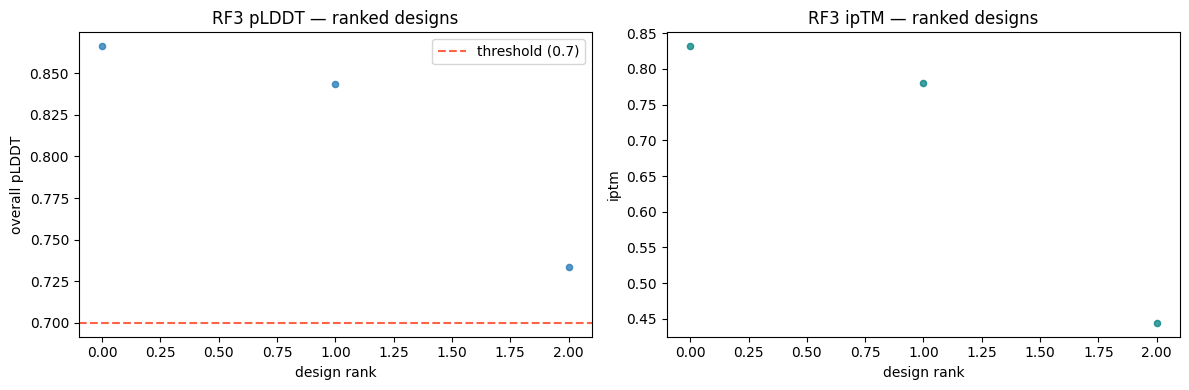

In [15]:
from rf3_metrics_foundry import gather_rf3_metrics_foundry

# Enzyme design: single chain (A), no interface target chains to score separately.
# Use overall_plddt and ranking_score for ranking.
plddt_threshold = 0.7

OUT_CSV = f'{scores_dir}/rf3_gathered_metrics.csv'

df_rf3 = gather_rf3_metrics_foundry(
    parent=rf3_out_dir,
    binder_chain_idx=0,
    out_csv=OUT_CSV,
)

print(f'Total RF3 predictions : {len(df_rf3)}')
print(f'Available columns     : {list(df_rf3.columns)}\n')

plddt_col = 'overall_plddt'
if plddt_col in df_rf3.columns:
    df_pass = df_rf3[df_rf3[plddt_col] >= plddt_threshold]
    print(f'Passing (pLDDT >= {plddt_threshold}): {len(df_pass)} / {len(df_rf3)}')
    display(df_rf3.sort_values(plddt_col, ascending=False).head(10))

    ranked = df_rf3.sort_values(plddt_col, ascending=False).reset_index(drop=True)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].scatter(ranked.index, ranked[plddt_col], alpha=0.75, s=20)
    axes[0].axhline(plddt_threshold, color='tomato', linestyle='--',
                    label=f'threshold ({plddt_threshold})')
    axes[0].set_xlabel('design rank'); axes[0].set_ylabel('overall pLDDT')
    axes[0].set_title('RF3 pLDDT — ranked designs'); axes[0].legend()

    if 'iptm' in df_rf3.columns:
        axes[1].scatter(ranked.index, ranked['iptm'], alpha=0.75, s=20, color='teal')
        axes[1].set_xlabel('design rank'); axes[1].set_ylabel('iptm')
        axes[1].set_title('RF3 ipTM — ranked designs')
    else:
        axes[1].axis('off')

    plt.tight_layout()
    plt.show()
else:
    display(df_rf3.head())